In [1]:
from google.colab import files
uploaded = files.upload()  # Upload Airbnb_Open_Data.xlsx

Saving 1730285881-Airbnb_Open_Data.xlsx to 1730285881-Airbnb_Open_Data.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Smart loading for Excel or CSV
file_name = "1730285881-Airbnb_Open_Data.xlsx"

df = None
try:
    df = pd.read_excel(file_name, engine="openpyxl")
    print("✅ Excel file loaded successfully!")
except Exception as e1:
    try:
        df = pd.read_csv(file_name)
        print("✅ CSV file loaded successfully!")
    except Exception as e2:
        print("❌ Could not load dataset. Check the file name or format.")
        print("Excel error:", e1)
        print("CSV error:", e2)

print("\n🔹 Dataset shape:", df.shape)
df.head()

✅ Excel file loaded successfully!

🔹 Dataset shape: (102599, 26)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
print("Available columns:", df.columns.tolist())

# Try to find the column with 'price' in its name
price_col = None
for c in df.columns:
    if "price" in c.lower():
        price_col = c
        break

if price_col is None:
    raise ValueError("❌ No price column found! Please check column names.")

print("✅ Price column detected as:", price_col)

# Clean data
df = df.drop_duplicates()
df = df.dropna(subset=[price_col])
df = df.fillna(df.median(numeric_only=True))

print("✅ Data cleaned. Rows remaining:", len(df))

Available columns: ['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']
✅ Price column detected as: price
✅ Data cleaned. Rows remaining: 101811


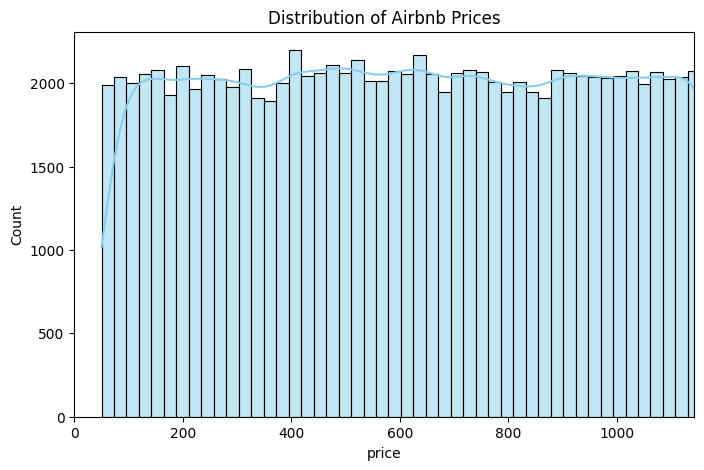

In [33]:
#1.Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df[price_col], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Airbnb Prices")
plt.xlim(0, df[price_col].quantile(0.95))
plt.show()


/tmp/ipython-input-4198910531.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette='magma')


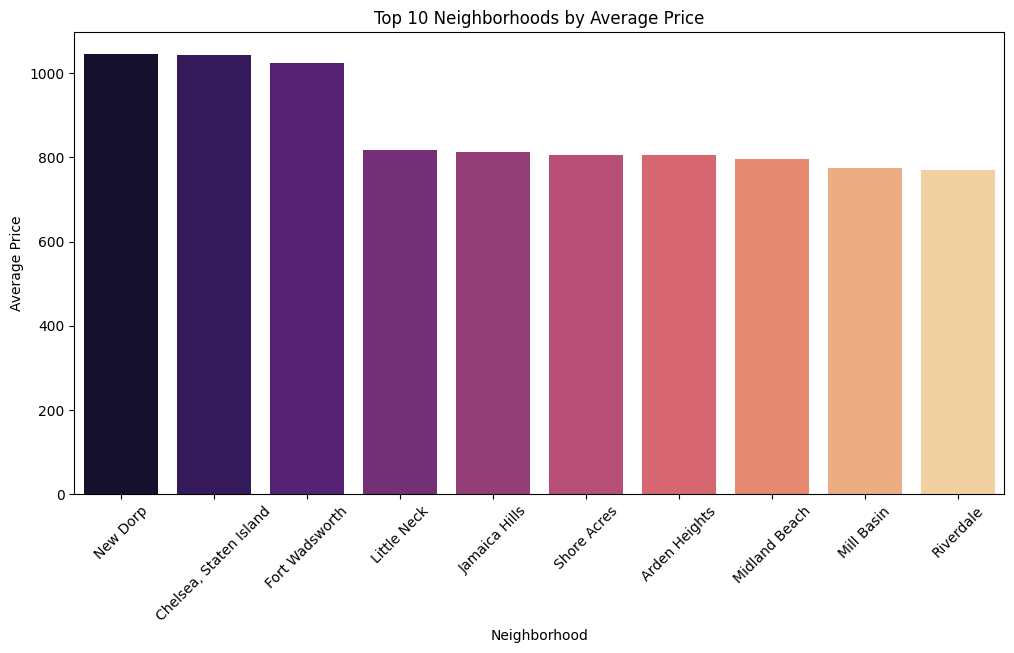

In [25]:
#2.Top 10 Neighborhoods by Average Price
avg_price = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_price.index, y=avg_price.values, palette='magma')
plt.title('Top 10 Neighborhoods by Average Price')
plt.xlabel('Neighborhood')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

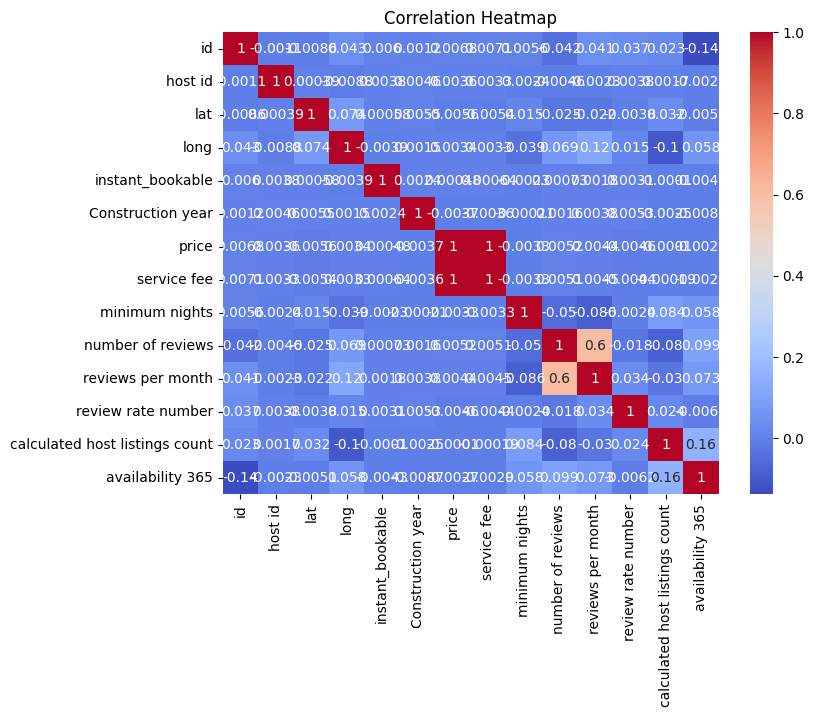

In [35]:
#3. Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

/tmp/ipython-input-1136576053.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room type', data=df, palette='pastel')


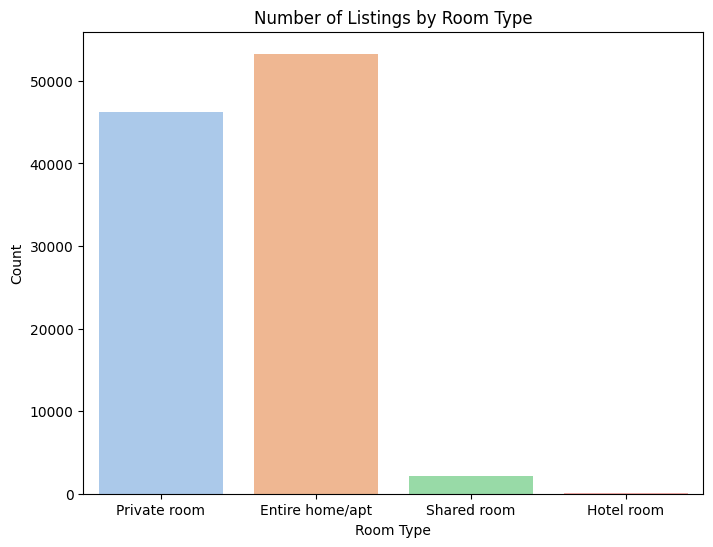

In [32]:
# 4. Room Type Distribution
plt.figure(figsize=(8,6))
sns.countplot(x='room type', data=df, palette='pastel')
plt.title('Number of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

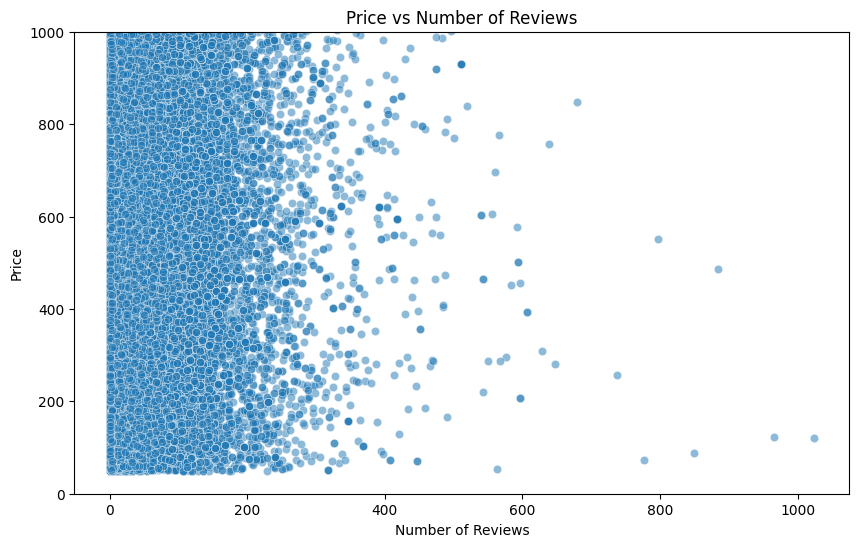

In [36]:
# 5. Price vs Number of Reviews
plt.figure(figsize=(10,6))
sns.scatterplot(x='number of reviews', y='price', data=df, alpha=0.5)
plt.title('Price vs Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.ylim(0, 1000)
plt.show()